<a href="https://colab.research.google.com/github/isha1982/Project/blob/main/Dragon_Real_Estate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 import pandas as pd

In [ ]:
housing = pd.read_csv("/content/drive/MyDrive/ml")
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.78420,0.0,8.14,0,0.538,5.990,81.7,4.2579,4,307,21.0,386.75,14.67,17.5
3,0.80271,0.0,8.14,0,0.538,5.456,36.6,3.7965,4,307,21.0,288.99,11.69,20.2
4,0.72580,0.0,8.14,0,0.538,5.727,69.5,3.7965,4,307,21.0,390.95,11.28,18.2


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     491 non-null    float64
 1   ZN       491 non-null    float64
 2   INDUS    491 non-null    float64
 3   CHAS     491 non-null    int64  
 4   NOX      491 non-null    float64
 5   RM       491 non-null    float64
 6   AGE      491 non-null    float64
 7   DIS      491 non-null    float64
 8   RAD      491 non-null    int64  
 9   TAX      491 non-null    int64  
 10  PTRATIO  491 non-null    float64
 11  B        491 non-null    float64
 12  LSTAT    491 non-null    float64
 13  MEDV     491 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 53.8 KB


In [ ]:
print(housing.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
housing['CHAS'].value_counts()

,count
CHAS,
0,456
1,35


In [ ]:
housing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000,491.000000
mean,3.715448,11.532587,11.270774,0.071283,0.556034,6.285859,68.599185,3.740859,9.714868,411.924644,18.481059,355.587434,12.674807,22.496945
std,8.711922,23.631179,6.909162,0.257560,0.117256,0.708420,28.337732,2.110563,8.785433,169.626590,2.150422,92.462141,7.137704,9.264030
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082100,0.000000,5.160000,0.000000,0.448000,5.882000,44.050000,2.075400,4.000000,279.000000,17.400000,374.695000,7.065000,16.800000
50%,0.268380,0.000000,9.900000,0.000000,0.538000,6.211000,77.700000,3.099200,5.000000,337.000000,19.100000,391.340000,11.380000,21.200000
75%,3.805910,17.750000,18.100000,0.000000,0.631000,6.627000,94.100000,5.100400,24.000000,666.000000,20.200000,396.220000,16.950000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


array([[<Axes: title={'center': 'CRIM'}>, <Axes: title={'center': 'ZN'}>,
        <Axes: title={'center': 'INDUS'}>,
        <Axes: title={'center': 'CHAS'}>],
       [<Axes: title={'center': 'NOX'}>, <Axes: title={'center': 'RM'}>,
        <Axes: title={'center': 'AGE'}>, <Axes: title={'center': 'DIS'}>],
       [<Axes: title={'center': 'RAD'}>, <Axes: title={'center': 'TAX'}>,
        <Axes: title={'center': 'PTRATIO'}>,
        <Axes: title={'center': 'B'}>],
       [<Axes: title={'center': 'LSTAT'}>,
        <Axes: title={'center': 'MEDV'}>, <Axes: >, <Axes: >]],
      dtype=object)

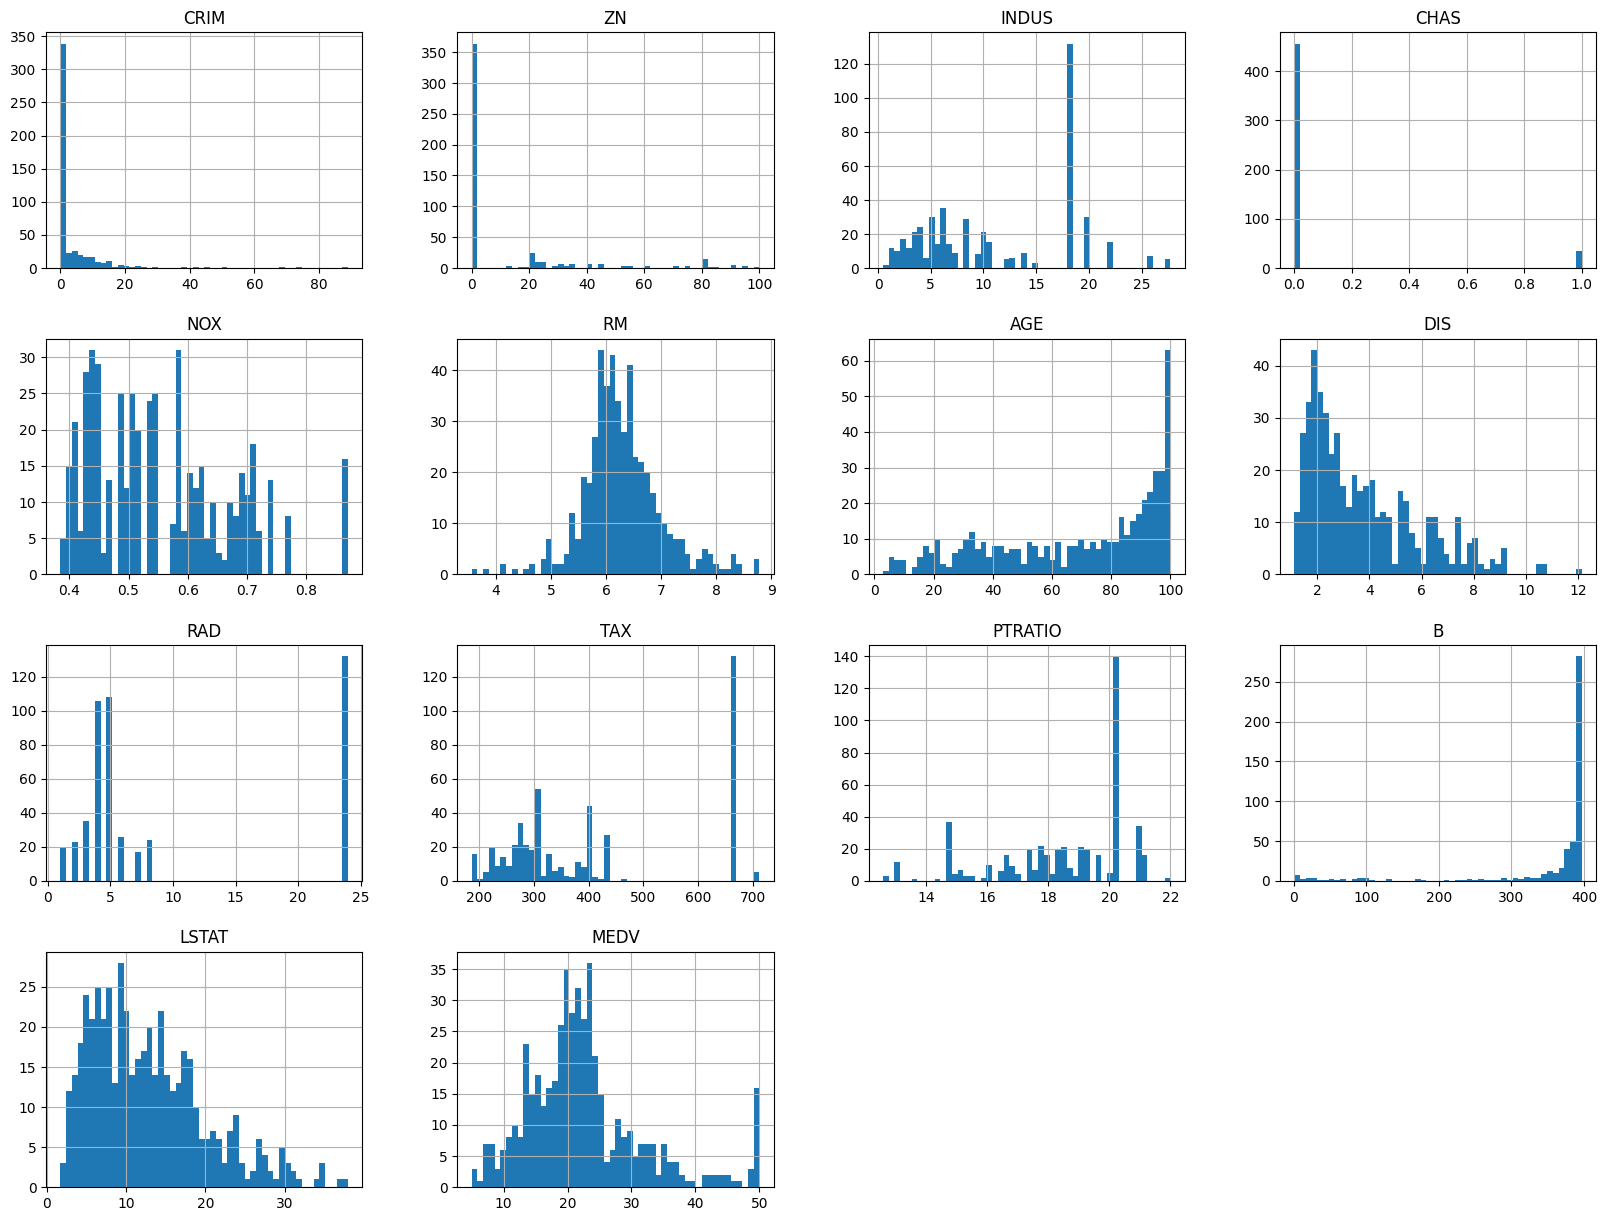

In [ ]:
####### for plotting histogram
import matplotlib.pyplot as plt
housing.hist(bins=50,figsize=(20,15))

In [ ]:
######## TRAIN TEST SPLITTING

In [ ]:
import numpy as np
def split_train_test(data,test_ratio):
  np.random.seed(42)
  shuffled = np.random.permutation(len(data))
  test_set_size = int(len(data)*test_ratio)
  test_indices = shuffled[:test_set_size]
  train_indices = shuffled[test_set_size:]
  return data.iloc[train_indices],data.iloc[test_indices]

In [ ]:
train_set,test_set = split_train_test(housing,0.2)
print("rows in train_set",len(train_set),"\nrows in test_set",len(test_set))

rows in train_set 393 
rows in test_set 98


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing['CHAS']):
  strat_train_set = housing.loc[train_index]
  strat_test_set = housing.loc[test_index]


In [ ]:
strat_test_set.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,4.073414,11.171717,10.633636,0.070707,0.538777,6.279808,65.734343,4.070122,9.262626,399.666667,18.607071,366.693232,12.102626,21.894949
std,11.053129,20.856673,6.926782,0.257639,0.113193,0.570492,28.361940,2.338396,8.520786,171.262479,1.885457,76.004221,6.613650,7.390940
min,0.010960,0.000000,1.250000,0.000000,0.389000,4.963000,6.200000,1.386100,1.000000,188.000000,12.600000,9.320000,3.010000,5.000000
25%,0.073340,0.000000,5.160000,0.000000,0.442900,5.939000,42.350000,2.257100,4.000000,278.000000,17.700000,377.365000,7.665000,18.550000
50%,0.171200,0.000000,8.560000,0.000000,0.515000,6.226000,71.900000,3.331700,5.000000,330.000000,18.900000,393.290000,10.400000,21.700000
75%,2.234475,20.000000,18.100000,0.000000,0.597000,6.617000,91.650000,5.502700,8.000000,666.000000,20.200000,396.900000,15.685000,24.750000
max,88.976200,80.000000,27.740000,1.000000,0.871000,8.266000,100.000000,10.710300,24.000000,711.000000,22.000000,396.900000,31.990000,46.000000


In [ ]:
strat_test_set['CHAS'].value_counts()

,count
CHAS,
0,92
1,7


In [ ]:
strat_train_set['CHAS'].value_counts()

,count
CHAS,
0,364
1,28


In [ ]:
92/7

13.142857142857142

In [ ]:
364/28

13.0

In [ ]:
corr_matrix = housing.corr()
corr_matrix['MEDV'].sort_values(ascending=False)

,MEDV
MEDV,1.000000
RM,0.693553
ZN,0.367820
B,0.334869
DIS,0.251412
CHAS,0.177912
AGE,-0.375421
RAD,-0.382670
CRIM,-0.390442
NOX,-0.425733


array([[<Axes: xlabel='MEDV', ylabel='MEDV'>,
        <Axes: xlabel='RM', ylabel='MEDV'>,
        <Axes: xlabel='LSTAT', ylabel='MEDV'>,
        <Axes: xlabel='ZN', ylabel='MEDV'>],
       [<Axes: xlabel='MEDV', ylabel='RM'>,
        <Axes: xlabel='RM', ylabel='RM'>,
        <Axes: xlabel='LSTAT', ylabel='RM'>,
        <Axes: xlabel='ZN', ylabel='RM'>],
       [<Axes: xlabel='MEDV', ylabel='LSTAT'>,
        <Axes: xlabel='RM', ylabel='LSTAT'>,
        <Axes: xlabel='LSTAT', ylabel='LSTAT'>,
        <Axes: xlabel='ZN', ylabel='LSTAT'>],
       [<Axes: xlabel='MEDV', ylabel='ZN'>,
        <Axes: xlabel='RM', ylabel='ZN'>,
        <Axes: xlabel='LSTAT', ylabel='ZN'>,
        <Axes: xlabel='ZN', ylabel='ZN'>]], dtype=object)

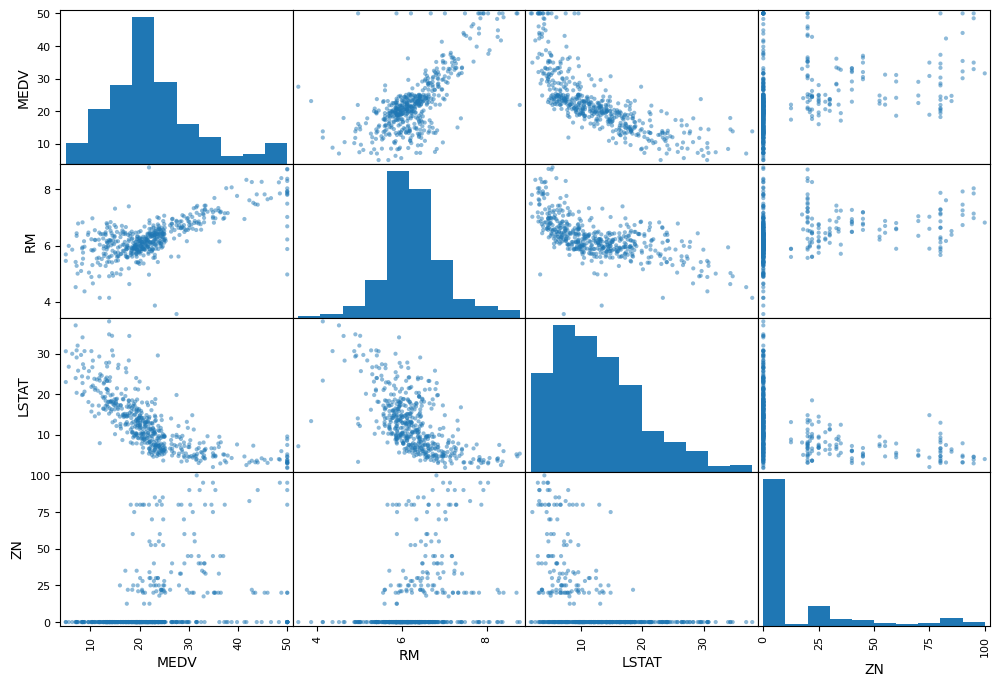

In [ ]:
from pandas.plotting import scatter_matrix
attribute = ['MEDV','RM','LSTAT','ZN']
scatter_matrix(housing[attribute],figsize=(12,8))

TRYING OUT ATTRIBUTE COMBINATION

In [ ]:
housing["TAXRM"] = housing['TAX']/housing['RM']
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAXRM
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,45.019011
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,37.688834
2,0.78420,0.0,8.14,0,0.538,5.990,81.7,4.2579,4,307,21.0,386.75,14.67,17.5,51.252087
3,0.80271,0.0,8.14,0,0.538,5.456,36.6,3.7965,4,307,21.0,288.99,11.69,20.2,56.268328
4,0.72580,0.0,8.14,0,0.538,5.727,69.5,3.7965,4,307,21.0,390.95,11.28,18.2,53.605727


In [ ]:
corr_matrix = housing.corr()
corr_matrix['MEDV'].sort_values(ascending=False)

,MEDV
MEDV,1.000000
RM,0.693553
ZN,0.367820
B,0.334869
DIS,0.251412
CHAS,0.177912
AGE,-0.375421
RAD,-0.382670
CRIM,-0.390442
NOX,-0.425733


<Axes: xlabel='TAXRM', ylabel='MEDV'>

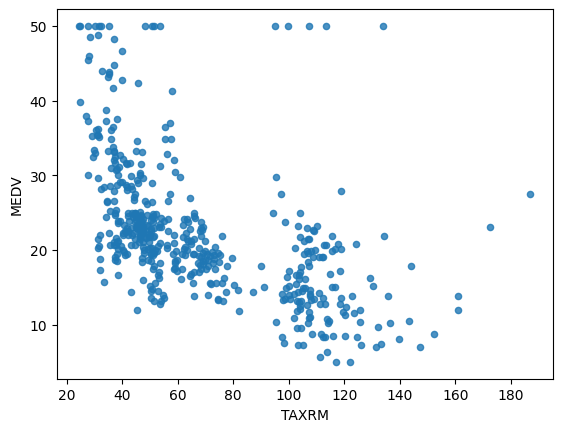

In [ ]:
housing.plot(kind="scatter",x="TAXRM",y="MEDV",alpha=0.8)

In [ ]:
housing = strat_train_set.drop("MEDV",axis=1)
housing_labels = strat_train_set["MEDV"].copy()

MISSING ATTRIBUTE

1 get rid of the missing dara points
2. get rid of whole attribute
3.set the value to same value(0,mean or median)

In [ ]:
a = housing.dropna(subset=["RM"])
a.shape

(392, 13)

In [ ]:
housing.drop("RM",axis=1).shape


(392, 12)

In [ ]:
median = housing["RM"].median()
housing["RM"].fillna(median)

,RM
160,6.546
32,6.030
486,6.593
371,4.652
424,5.627
...,...
55,6.417
238,8.259
100,5.928
239,6.108


In [ ]:
housing.shape

(392, 13)

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
imputer.fit(housing)

SimpleImputer(strategy='median')

In [ ]:
 imputer.statistics_

array([3.39945e-01, 0.00000e+00, 9.90000e+00, 0.00000e+00, 5.38000e-01,
       6.20900e+00, 7.89500e+01, 3.07930e+00, 5.00000e+00, 3.51500e+02,
       1.91000e+01, 3.90925e+02, 1.19750e+01])

In [ ]:
X = imputer.transform(housing)
housing_tr = pd.DataFrame(X,columns=housing.columns)
housing_tr.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,3.625044,11.623724,11.431684,0.071429,0.560392,6.287388,69.322704,3.657703,9.829082,415.020408,18.449235,352.782653,12.819311
std,8.028259,24.305481,6.904256,0.257869,0.118001,0.739827,28.321969,2.043876,8.858009,169.290711,2.213398,96.056863,7.264951
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,0.083827,0.000000,5.175000,0.000000,0.449000,5.873500,45.550000,2.044600,4.000000,281.000000,17.225000,372.387500,6.927500
50%,0.339945,0.000000,9.900000,0.000000,0.538000,6.209000,78.950000,3.079300,5.000000,351.500000,19.100000,390.925000,11.975000
75%,4.128648,0.000000,18.100000,0.000000,0.647000,6.630250,94.825000,4.793450,24.000000,666.000000,20.200000,395.810000,17.152500
max,73.534100,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


##SCIKIT-LEARN DESIGN
CREATING A PIPELINE
1.Estimators
2.Transformer
3.Predictors

##FEATURE SCALING
1.Min-max SCALING
(value-min)/(max-min)
2.Standardization
(value-mean)/std

##CREATING A PIPELINE

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
my_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy="median")),
      ('std_scaler',StandardScaler())
])


In [ ]:
housing_num_tr = my_pipeline.fit_transform(housing_tr)

In [ ]:
housing_num_tr

array([[-0.4438012 , -0.47884587, -1.07051604, ..., -0.83654096,
         0.3979532 , -1.03219998],
       [-0.42351812, -0.47884587, -0.65574944, ..., -0.24845809,
         0.41650757,  0.82427698],
       [-0.44430132, -0.47884587,  0.07226747, ...,  1.15389338,
         0.40868972, -0.43404779],
       ...,
       [-0.4307431 , -0.47884587, -0.20617724, ..., -0.29369523,
        -0.082063  ,  0.4052948 ],
       [-0.44610226,  2.81679915, -1.12997559, ..., -0.92701525,
         0.41807114, -0.86129936],
       [ 0.00848918, -0.47884587,  0.96706116, ...,  0.79199623,
         0.40285239,  0.25231118]])

In [ ]:
##SELECTING A DESIRE MODEL FOR DRAGON REAL ESTATES

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
# Now fit the model with the correct data
#model = LinearRegression()
#model = DecisionTreeRegressor()
model = RandomForestRegressor()
model.fit(housing_num_tr, housing_labels)

RandomForestRegressor()

In [ ]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
prepared_data = my_pipeline.transform(some_data)
model.predict(prepared_data)

array([27.749, 17.5  , 22.492,  9.426, 12.2  ])

In [ ]:
list(some_labels)

[29.4, 16.6, 22.4, 10.5, 12.8]

EVALUATING THE MODEL


In [ ]:
from sklearn.metrics import mean_squared_error
housing_prediction = model.predict(housing_num_tr)
mse = mean_squared_error(housing_labels,housing_prediction)
rmse = np.sqrt(mse)
rmse

np.float64(1.2791397180790471)

USING BETTRE EVALUATION TECHNIQUE - CROSS VALIDATION

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,housing_num_tr,housing_labels,scoring="neg_mean_squared_error",cv=10)
rmse_scores = np.sqrt(-scores)
rmse_scores

array([2.43185832, 3.29315179, 3.00909013, 2.42490946, 5.66984252,
       2.26597241, 2.73356051, 3.23135873, 4.48792113, 3.49985474])

In [ ]:
def print_scores(scores):
    print("scores:",scores)
    print("Mean:",scores.mean())
    print("Standard deviation:",scores.std())


In [ ]:
print_scores(rmse_scores)

scores: [2.43185832 3.29315179 3.00909013 2.42490946 5.66984252 2.26597241
 2.73356051 3.23135873 4.48792113 3.49985474]
Mean: 3.304751973367368
Standard deviation: 1.0032912597527592


SAVING THE MODEL

In [ ]:

from joblib import dump,load
dump(model,'Dragon.joblib')
from google.colab import files
files.download('Dragon.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()
from joblib import dump,load
dump(model,'Dragon.joblib')

Saving Dragon (1).joblib to Dragon (1).joblib


['Dragon.joblib']

TESTING THE MODEL ON TEST DATA

In [ ]:
from typing_extensions import final
x_test = strat_test_set.drop("MEDV",axis=1)
y_test = strat_test_set["MEDV"].copy()
x_test_prepared = my_pipeline.transform(x_test)
final_prediction = model.predict(x_test_prepared)
final_mse = mean_squared_error(y_test,final_prediction)
final_rmse = np.sqrt(final_mse)
##print(final_prediction,list(y_test))

In [ ]:
final_rmse

np.float64(2.844142721134405)

In [ ]:
prepared_data[0]

array([-0.4438012 , -0.47884587, -1.07051604, -0.2773501 , -0.42759461,
        0.35000459, -1.28059582, -0.25739068, -0.5458623 , -0.70395186,
       -0.83654096,  0.3979532 , -1.03219998])

# USING THE MODEL

In [ ]:
from joblib import dump, load
model = load('Dragon.joblib')

In [ ]:
input = np.array([[-0.4438012 , -0.47884587, -1.07051604, -0.2773501 , -0.42759461,
        0.35000459, -1.28059582, -0.25739068, -0.5458623 , -0.70395186,
       -0.83654096,  0.3979532 , -1.03219998]])
model.predict(input)

array([27.749])